Importing Libraries

In [22]:
import os
import cv2
import numpy as np
import torch
import webcolors
import torchvision
from tqdm import tqdm
import pandas as pd
from torchvision import transforms
from PIL import Image
from torchvision.transforms.functional import resize
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from collections import Counter
import json
from fashn_human_parser import FashnHumanParser
import colour # for Delta-E color math

DEEPLABV3 MODEL - COLOUR EXTRACTION

In [19]:
MAJOR_RGB_COLOURS = {
    "Red": [
        [200, 0, 0], [225, 32, 54], [139, 0, 0], [238, 21, 52], [192, 22, 49],
        [215, 66, 83], [169, 50, 57], [215, 74, 53], [246, 106, 99], [234, 34, 59],
        [174, 6, 35], [200, 94, 79], [232, 47, 69]
    ],

    "Orange": [
        [251, 145, 38], [250, 158, 45], [245, 124, 54], [255, 140, 0], 
        [248, 143, 103], [227, 89, 75], [213, 99, 75]
    ],

    "Brown": [
        [101, 67, 33], [133, 83, 60], [109, 42, 26], [153, 74, 54], [91, 69, 54],
        [103, 86, 68], [152, 122, 92], [123, 54, 42], [135, 64, 46], [110, 55, 52],
        [71, 18, 21], [126, 71, 60] # Moved from Red/Orange to Brown
    ],

    "Blue": [
        [0, 0, 200], [0, 84, 190], [0, 50, 128], [73, 119, 180], [63, 97, 148],
        [44, 56, 88], [72, 99, 146], [40, 69, 116], [108, 129, 164], [151, 174, 200],
        [149, 191, 220], [81, 105, 134], [9, 70, 101] 
        # Deleted all values where R, G, and B were all below 40
    ],

    "Green": [
        [0, 200, 0], [32, 100, 96], [48, 185, 162], [64, 110, 101], 
        [54, 63, 48], [32, 48, 40]
        # Removed the "Grey-Greens" that were catching runway floor reflections
    ],

    "Yellow": [
        [255, 255, 0], [248, 200, 59], [211, 151, 52], [243, 190, 80], 
        [247, 179, 44], [234, 168, 44], [251, 179, 58]
    ],

    "Pink": [
        [246, 15, 89], [247, 19, 88], [255, 100, 200], [244, 95, 130], 
        [197, 34, 75], [158, 64, 135]
    ],

    "Purple": [
        [95, 35, 78], [82, 71, 142], [50, 46, 88], [151, 117, 158], [106, 38, 69]
    ],

    "White": [
        [255, 255, 255], [240, 240, 246], [235, 233, 235], [225, 225, 231]
    ],

    "Black": [
        [0, 0, 0], [15, 15, 25], [21, 21, 28], [31, 26, 33], [22, 20, 27],
        [26, 20, 24], [29, 21, 26], [28, 23, 24], 
        [22, 22, 35], [23, 24, 40], [28, 32, 59] # Rescued from "Blue"
    ],

    "Grey": [
        [128, 128, 130], [169, 152, 154], [198, 195, 204], [117, 112, 114],
        [82, 83, 100], [55, 56, 66], [71, 62, 69], [35, 39, 49],
        [167, 185, 185], [105, 133, 138] # Rescued from "Green"
    ],

    "Cream/Khaki/Beige": [
        [239, 232, 230], [244, 226, 198], [238, 227, 218], [207, 164, 135],
        [220, 205, 203], [237, 215, 204], [224, 212, 199]
    ],

    "Skin":
    [[148, 101, 86], [119, 90, 86], [145, 80, 57], [120, 82, 81], [65, 34, 18], [131, 89, 77], [23,16,18], [89, 57, 49], [72, 42, 36], [111, 84, 76],
     [26,26,43], [30,23,30], [31,22,20], [43,23,19], [44,30,43], [45,35,45], [51,32,24], [52,30,26], [55,31,31],[56,42,58], 
     [64,39,40], [66,41,50], [71,48,52], [76,44,38], [84,61,71], [94,60,62], [95,55,53], [101,57,56], [101,73,77], [101,75,67], [103,70,69], 
     [106,51,20], [107,68,65], [112,73,74], [113,95,108], [122,86,86], [128,100,97], [129,75,68], [129,79,79], [134,102,98], [147,96,90], 
     [150,138,147], [153,94,87], [154,126,139], [156,125,121], [159,113,95], [160,119,121], [162,108,102], [166,110,100], [177,132,129], 
     [182,122,112], [201,167,176], [204,161,148], [208,153,134], [214,163,156], [215,180,173], [230,179,168], [232,188,174], [233,198,190], 
     [233,211,212], [138, 90, 81], [95, 63, 56], [77, 31, 21], [77, 25, 18], [89, 47, 40], [147, 103, 97], [128, 72, 52], [136, 79, 63],
     [209, 155, 138]
     ],
     "Highlights": [[178, 161, 165], [67,65,86], [135, 102, 100], [191, 162, 163], [114,109,128], [126,111,127], [142,110,99], [146,124,123], [151,130,129], [159,135,145], [197,164,158], 
                   [208,142,106], [198, 158, 154], [155, 136, 135], [35, 34, 43], [72, 58, 61], [61, 52, 61], [168, 131, 123], [217,192,186], [142,149,184], [194, 185, 183],
                   [192, 111, 78], [186, 128, 106], [178, 113, 74], [167, 147, 147], [242, 231, 238], [248, 172, 68], [117, 90, 87], [22, 22, 35], [39, 40, 55], [23, 24, 40], [28, 32, 59]],
    
    "Shadows": [[35, 20, 24], [53, 43, 44], [106, 90, 93], [60, 31, 28], [68, 41, 35], [54, 35, 47], [95, 85, 100], [125, 116, 119], [75, 38, 36], [50, 25, 27], [23,16,18], [26,26,43], 
                [30,23,30], [31,22,20], [43,23,19], [44,30,43], [52,30,26], [14, 28, 28]],

    "BG": [[232, 220, 219], [207, 207, 219], [189,209,245], [179,203,240],[194,201,217], [105,106,120], [54, 44, 49], [126, 115, 118], [209, 202, 206]]

}

In [12]:
# Convert the grouped RGB dictionary into flattened Lab values
FLAT_LAB_COLOURS = {}
for colour_name, rgb_list in MAJOR_RGB_COLOURS.items():
    for i, rgb in enumerate(rgb_list):
        # Convert the RGB pixel to Lab space matching OpenCV's scale
        rgb_pixel = np.uint8([[[rgb[0], rgb[1], rgb[2]]]])
        lab_pixel = cv2.cvtColor(rgb_pixel, cv2.COLOR_RGB2LAB)[0][0]
        
        # Save it with a unique index (e.g., "Red_0", "Red_1")
        FLAT_LAB_COLOURS[f"{colour_name}_{i}"] = lab_pixel

In [13]:
def get_colour_name(lab_pixel):
    distances = {name: np.linalg.norm(lab_pixel - val) for name, val in FLAT_LAB_COLOURS.items()}
    best_match = min(distances, key=distances.get)
    return best_match.split('_')[0]  # Return the base colour name without the index

In [23]:
def process_all_colours(main_folder_path, output_csv_path):
    device = torch.device("cuda" if torch.cude.is_available() else "cpu")
    all_brand_data = []

    # Load the pre-trained DeepLabV3 model for segmentation
    model2 = torchvision.models.segmentation.deeplabv3_mobilenet_v3_large(weights='DEFAULT').to(device)
    model2.eval()

    preprocess = transforms.Compose([
    transforms.Resize((520,520)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

    for brand_name in os.listdir(main_folder_path):
        brand_folder = os.path.join(main_folder_path, brand_name)
        
        if not os.path.isdir(brand_folder):
            continue

        print(f"Processing brand: {brand_name}")
        good_img = [ f for f in os.listdir(brand_folder) if f.lower().endswith(('.jpg','.jpeg', '.png'))]


        for img_name in tqdm(good_img, desc=f"analyzing {brand_name}"):
            img_path = os.path.join(brand_folder, img_name)

            try:
                # load and preprocess the image
                input_image = Image.open(img_path).convert("RGB")
                input_tensor = preprocess(input_image).unsqueeze(0).to(device) # Add batch dimension

                with torch.no_grad():
                    outputs = model2(input_tensor)['out'][0]
                    
                mask = torch.argmax(outputs, dim=0).cpu().numpy()                
                garment_masks = (mask == 15) #15 is for a person in the model
                
                # convert OG image to LAB for colour analysis
                mask_img = input_image.resize((520, 520))
                img_np = np.array(mask_img)
                img_lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)      
                pixels = img_lab[garment_masks]

                if len(pixels) > 0:
                    if len(pixels) > 1500:
                        idx = np.random.choice(len(pixels), 1500, replace=False)
                        pixels = pixels[idx]

                    # kmeans to find dominant colours
                    n = 7
                    kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
                    kmeans.fit(pixels)
                    
                    found_colours = [get_colour_name(centroid) for centroid in kmeans.cluster_centers_]
                    unique_names = list(set(found_colours))

                    # if "Black" in unique_names and len(unique_names) > 1:
                    #     unique_names.remove("Black")
                    if "Skin" in unique_names:
                        unique_names.remove("Skin")
                    if "Shadows" in unique_names:
                        unique_names.remove("Shadows")
                    if "BG" in unique_names:
                        unique_names.remove("BG")
                    if "Highlights" in unique_names:
                        unique_names.remove("Highlights")
                    # if "Grey" in unique_names:
                    #     unique_names.remove("Grey")
                    

                    if unique_names and len(unique_names) > 0:
                        all_brand_data.append({
                            "brand": brand_name,
                            "image": img_name,
                            "colours": ", ".join(unique_names)})
                
                
            except Exception as e:
                print(f"skipping {img_name} due to error: {e}")
        
        df = pd.DataFrame(all_brand_data)
        df.to_csv(output_csv_path, index=False)        
        print(f"Segmentation completed for {brand_name}.\n")

    return all_brand_data

In [24]:
main_folder_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\data\runway'
output_csv_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\stats\CSV\deeplab_runway_colours.csv'

extracted_colours = process_all_colours(main_folder_path, output_csv_path)

AttributeError: module 'torch' has no attribute 'cude'

In [ ]:
def process_all_colours1(main_folder_path, output_csv_path):
    # Initialize the high-end fashion parser (auto-detects GPU)
    parser = FashnHumanParser()
    
    # 18 Classes: 1: Hat, 2: Hair, 3: Sunglasses, 4: Upper-clothes, 
    # 5: Skirt, 6: Pants, 7: Dress, 8: Belt, 9: Left-shoe, etc.
    # We target classes: 4, 5, 6, 7 (Main garments)
    CLOTHING_IDS = [4, 5, 6, 7]
    
    # Reference LAB value for a "generic" skin tone to help filter residuals
    SKIN_REF_LAB = np.array([60, 15, 15]) 

    all_brand_data = []

    for brand_name in os.listdir(main_folder_path):
        brand_folder = os.path.join(main_folder_path, brand_name)
        if not os.path.isdir(brand_folder): continue

        images = [f for f in os.listdir(brand_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_name in tqdm(images, desc=f"Analyzing {brand_name}"):
            img_path = os.path.join(brand_folder, img_name)
            try:
                # Get the segmentation mask (ID for every pixel)
                # Output is a numpy array of same size as original image
                mask = parser.predict(img_path) 
                
                # Combine masks for all clothing items
                garment_mask = np.isin(mask, CLOTHING_IDS)
                
                # Load image for color extraction
                img_rgb = np.array(Image.open(img_path).convert("RGB"))
                img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
                
                pixels = img_lab[garment_mask]

                if len(pixels) > 0:
                    # Speed boost: Sample 2000 random pixels
                    if len(pixels) > 2000:
                        pixels = pixels[np.random.choice(len(pixels), 2000, replace=False)]

                    # K-Means for dominant colors
                    kmeans = KMeans(n_clusters=8, n_init=5, random_state=42).fit(pixels)
                    # Calculate how big each color cluster is
                    counts = Counter(kmeans.labels_)
                    total_pixels = sum(counts.values())
                    
                    final_colours = []
                    
                    for i, centroid in enumerate(kmeans.cluster_centers_):
                        # Calculate the percentage of the garment this color takes up
                        weight = counts[i] / total_pixels
                        
                        # Only keep the color if it makes up MORE than 15% of the outfit
                        if weight >= 0.15: 
                            name = get_colour_name(centroid)
                            
                            # Filter out your utility tags
                            if name not in ["BG", "Shadows", "Skin", "Highlights"]:
                                final_colours.append(name)

                    # Remove duplicates and save
                    unique_colours = list(set(final_colours))
                    if unique_colours:
                        all_brand_data.append({
                            "brand": brand_name,
                            "image": img_name,
                            "colours": ", ".join(unique_colours)
                        })

            except Exception as e:
                print(f"Error on {img_name}: {e}")

        # Checkpoint save
        pd.DataFrame(all_brand_data).to_csv(output_csv_path, index=False)
        print(f"Colour analysis completed for {brand_name}.\n")



    return all_brand_data

In [21]:
main_folder_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\data\runway'
output_csv_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\stats\CSV\runway_colours.csv'

extracted_colours = process_all_colours1(main_folder_path, output_csv_path)

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

Analyzing adage_studio_project_x_unrefyned: 100%|██████████| 5/5 [00:38<00:00,  7.79s/it]


Colour analysis completed for adage_studio_project_x_unrefyned.



Analyzing adama_paris: 100%|██████████| 15/15 [01:37<00:00,  6.49s/it]


Colour analysis completed for adama_paris.



...

Colour analysis completed for the_or_foundation.



Analyzing wote: 100%|██████████| 25/25 [01:25<00:00,  3.44s/it]


Colour analysis completed for wote.



Analyzing y'wande: 100%|██████████| 25/25 [01:24<00:00,  3.40s/it]

Colour analysis completed for y'wande.



OVERALL FREQUENCY OF COLOURS

VISUALIZATION

In [7]:
all_colour_names =[]
rejected_colours = ["Skin", "Shadows", "BG", "Highlights"]
df1 = pd.read_csv(output_csv_path)

for entry in df1['colours'].dropna():
    # split by comma because we saved them as a string in the CSV format
    names = entry.split(", ")
    filtered = [name for name in names if name not in rejected_colours]
    all_colour_names.extend(filtered)

# 2. Count and Sort
colour_count = Counter(all_colour_names)
sorted_colours = colour_count.most_common() # <-- This is a more concise way to sort by count

# 3. Prepare for Plotting
names = [item[0] for item in sorted_colours]
counts = [item[1] for item in sorted_colours]

total_colours = sum(counts)
percentages = [(count / total_colours) * 100 for count in counts]
plot_colours = [np.array(MAJOR_RGB_COLOURS[label][3])/255.0 for label in names]

# Print the top 5 colors for a quick check
print("Top 5 Colours across the entire runway:")
for i in range(5):
    print(f"{names[i]}: {counts[i]} garments ({percentages[i]:.2f}%)")

Top 5 Colours across the entire runway:
Cream/Khaki/Beige: 299 garments (14.84%)
Blue: 256 garments (12.70%)
Grey: 216 garments (10.72%)
Brown: 211 garments (10.47%)
White: 205 garments (10.17%)


JSON EXPORTATION

In [8]:
json_data = df1.to_dict(orient='records')
json_path = r'C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\JSON'
json_file = os.path.join(json_path, 'runway_colours.json')

with open(json_file, 'w') as f:
    json.dump(json_data, f, indent=4)
print(f"JSON file saved to {json_file}")

JSON file saved to C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\JSON\runway_colours.json


WHOLE RUNWAY STATS

Visualization report saved to: C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\overall_colour_frequency.png
Visualization report saved to: C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\overall_colour_distribution.png
Visualization report saved to: C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\overall_colour_palette.png


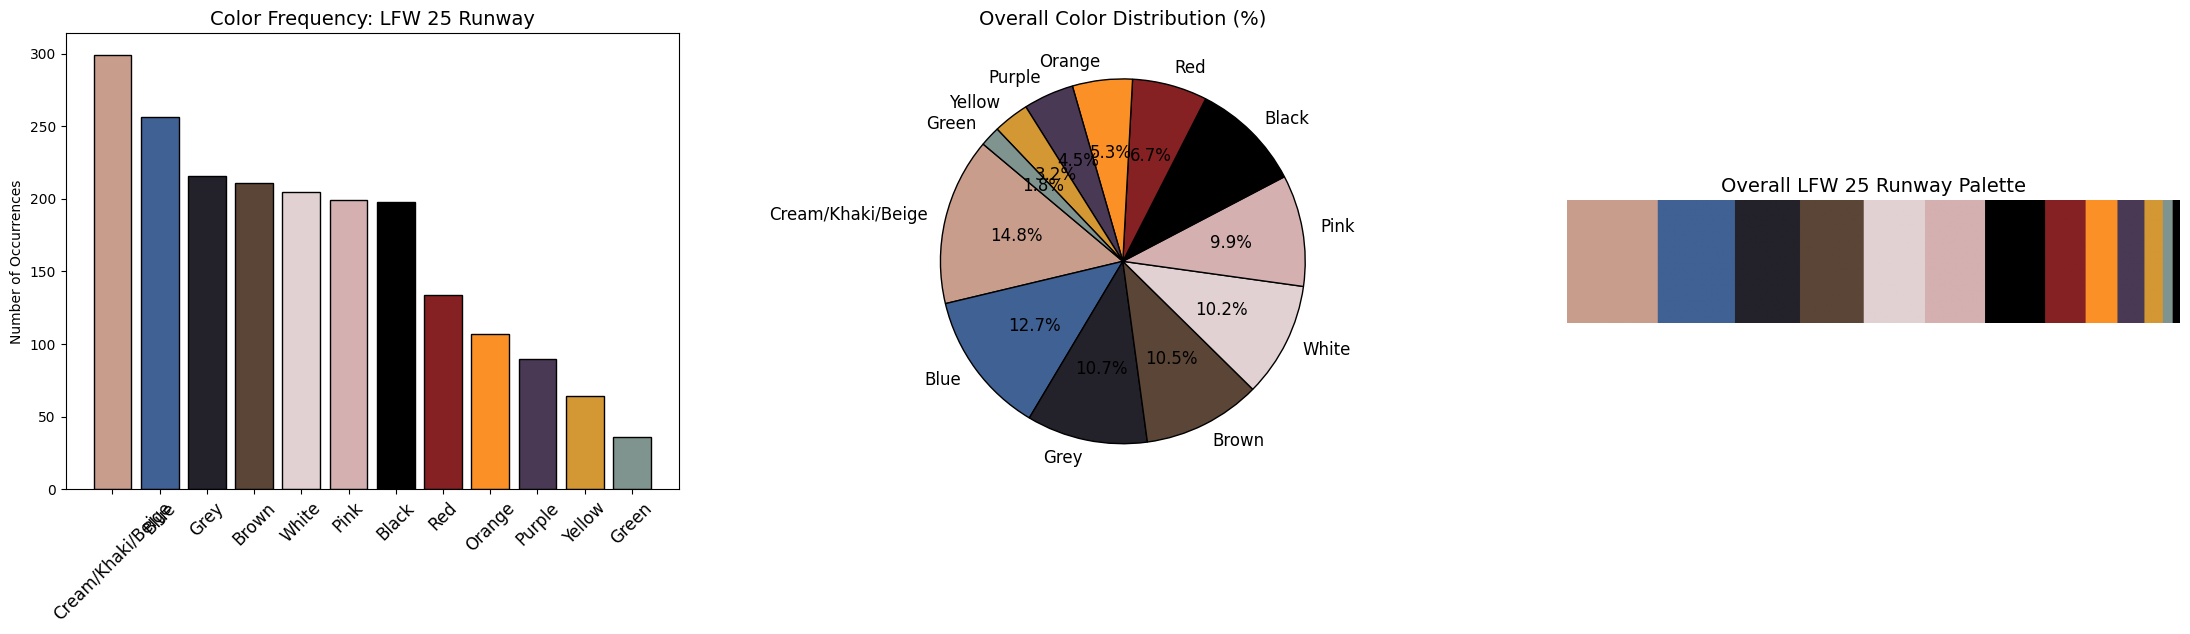

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# A. Bar Chart: Frequency 
axes[0].bar(names, counts, color=plot_colours, edgecolor='black')
axes[0].set_title('Color Frequency: LFW 25 Runway', fontsize=14)
axes[0].set_ylabel('Number of Occurrences')
axes[0].tick_params(axis='x', rotation=45, labelsize=12)

freq_img_path = r'C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\overall_colour_frequency.png'
plt.savefig(freq_img_path, dpi=300)
print(f"Visualization report saved to: {freq_img_path}")


# B. Percentage Chart: Distribution
axes[1].pie(percentages, labels=names, autopct='%1.1f%%', 
            colors=plot_colours, startangle=140, wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 12})
axes[1].set_title('Overall Color Distribution (%)', fontsize=14)

dist_img_path = r'C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\overall_colour_distribution.png'
plt.savefig(dist_img_path, dpi=300)
print(f"Visualization report saved to: {dist_img_path}")


# C. Color Palette: The "Runway Palette"
# We create a simple strip showing the dominant colors in order
palette_img = np.zeros((100, 500, 3))
start = 0
for i, perc in enumerate(percentages):
    end = start + int((perc / 100) * 500)
    palette_img[:, start:end] = plot_colours[i]
    start = end

axes[2].imshow(palette_img)
axes[2].axis('off')
axes[2].set_title('Overall LFW 25 Runway Palette', fontsize=14)

palette_img_path = r'C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\overall_colour_palette.png'
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(palette_img_path, dpi=300)
print(f"Visualization report saved to: {palette_img_path}")
plt.show()

BRAND SPECIFIC STATS

In [11]:
output_dir = r'C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats'
unique_brands = df1['brand'].unique()
brand_api_data = {}

for brand in unique_brands:
    brand_data = df1[df1['brand'] == brand]
    brand_colours = []
    
    for val in brand_data['colours'].dropna():
        names = val.split(", ")
        brand_colours.extend(names)
    
    if not brand_colours: 
        continue
    
    # count the colours for this brand and sort them by frequency
    brand_colour_count = Counter(brand_colours)
    sorted_brand_colours = dict(sorted(brand_colour_count.items(), key=lambda item: item[1], reverse=True))
    
    names = list(sorted_brand_colours.keys())
    counts = list(sorted_brand_colours.values())
    total_brand_colours = sum(counts)
    percentages = [(count / total_brand_colours) * 100 for count in counts]
    plot_colours = [np.array(MAJOR_RGB_COLOURS[label][3])/255.0 for label in names]
    print(f"\n Processing Brand: {brand}")
    
    # Prepare JSON data for this brand
    colour_info=[]
    for i in range(len(names)):
        colour_info.append({
            "colour": names[i],
            "count": counts[i],
            "percentage": percentages[i]
        })
    
    # assign it to the API data dictionary
    brand_api_data[brand] = colour_info

    # Print the top 5 colors for a quick check
    n = min(5, len(names)) # In case there are less than 5 colors for this brand
    print(f"\nTop {n} Colours across {brand} runway:")
    for i in range(n):
        print(f"{names[i]} is found in {percentages[i]:.2f}% of {brand}'s collection.")
        # export the JSON data for this brand
        
        brand_json_path = os.path.join(output_dir, f"{brand.replace(' ', '_')}_colours.json")
        with open(brand_json_path, 'w') as f:
            json.dump(colour_info, f, indent=4)
        
        print(f"JSON file saved for {brand} at: {brand_json_path}")
    
    # 4. Create the Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(f"Colour Analysis: {brand.upper()}", fontsize=20, fontweight='bold')

    # A. Bar Chart
    axes[0].bar(names, counts, color=plot_colours, edgecolor='black')
    axes[0].set_title('Frequency of Colours')
    axes[0].tick_params(axis='x', rotation=45)

    # B. Pie Chart
    axes[1].pie(percentages, labels=names, autopct='%1.1f%%', colors=plot_colours, 
                startangle=140, wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Distribution (%)')

    # C. Color Palette: The "Runway Palette"
    # We create a simple strip showing the dominant colors in order
    palette_img = np.zeros((100, 500, 3))
    start = 0
    for i, perc in enumerate(percentages):
        end = start + int((perc / 100) * 500)
        if i == len(percentages) - 1:  # Ensure the last color fills any remaining space
            end = 500

        palette_img[:, start:end] = plot_colours[i]
        start = end

    axes[2].imshow(palette_img)
    axes[2].axis('off')
    axes[2].set_title('Runway Palette', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 5. Save the report
    brand_filename = f"{brand.replace(' ', '_')}_report.png"
    plt.savefig(os.path.join(output_dir, brand_filename), dpi=200)
    plt.close() # Close plot to save memory during loop


print(f"COMPLETED! ALL BRAND STATS ARE SAVED IN: {output_dir}")


 Processing Brand: adage_studio_project_x_unrefyned

Top 3 Colours across adage_studio_project_x_unrefyned runway:
White is found in 50.00% of adage_studio_project_x_unrefyned's collection.
JSON file saved for adage_studio_project_x_unrefyned at: C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\adage_studio_project_x_unrefyned_colours.json
Grey is found in 33.33% of adage_studio_project_x_unrefyned's collection.
JSON file saved for adage_studio_project_x_unrefyned at: C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\adage_studio_project_x_unrefyned_colours.json
Blue is found in 16.67% of adage_studio_project_x_unrefyned's collection.
JSON file saved for adage_studio_project_x_unrefyned at: C:\Users\User\OneDrive\Desktop\Lagos-FW-2024-Analysis\Lagos-FW-2024-Analysis-1\outputs\stats\adage_studio_project_x_unrefyned_colours.json

 Processing Brand: adama_paris

Top 5 Colours across adama_paris runway: